## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Load Data

In [2]:
df = pd.read_csv(r'/Users/blaketracy/Downloads/stats (1).csv')

df = df.rename(columns={"last_name, first_name": "pitcher"})

## Define Variables 

In [3]:
target = "p_era"

predictors = [
    "k_percent",
    "bb_percent",
    "whiff_percent",
    "hard_hit_percent",
    "barrel_batted_rate",
    "xwoba",
    "woba"
]

labels = {
    "k_percent": "Strikeout Percentage",
    "bb_percent": "Walk Percentage",
    "whiff_percent": "Whiff Percentage",
    "hard_hit_percent": "Hard Hit Percentage",
    "barrel_batted_rate": "Barrel Rate",
    "xwoba": "Expected wOBA",
    "woba": "wOBA"
}

## Data Cleaning 

In [4]:
keep_cols = ["pitcher", "player_id", "year", "pa", target] + predictors
df = df[keep_cols].copy()

for c in [target] + predictors + ["pa"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()

## Correlation Analysis 

In [5]:
corr = df[[target] + predictors].corr(numeric_only=True)

print("\nCorrelation with ERA (p_era):")
print(corr[target].sort_values(ascending=False))


Correlation with ERA (p_era):
p_era                 1.000000
woba                  0.909677
xwoba                 0.805489
hard_hit_percent      0.416407
barrel_batted_rate    0.347813
bb_percent            0.184958
whiff_percent        -0.627148
k_percent            -0.707090
Name: p_era, dtype: float64


## Visualizations 

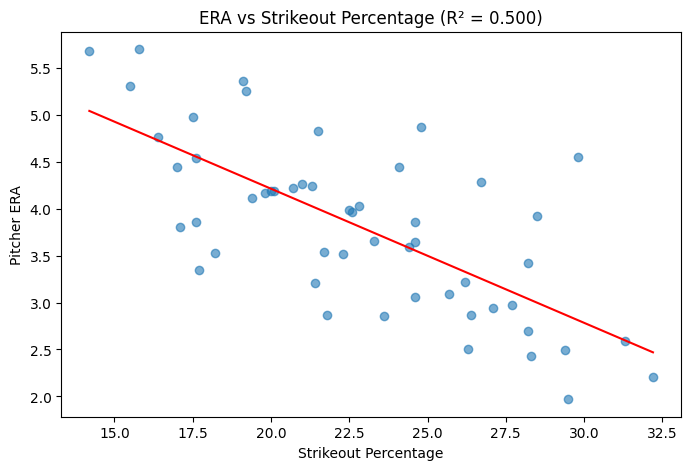

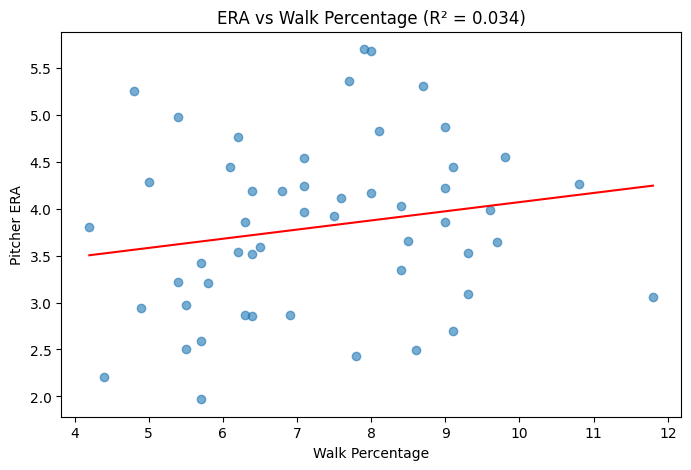

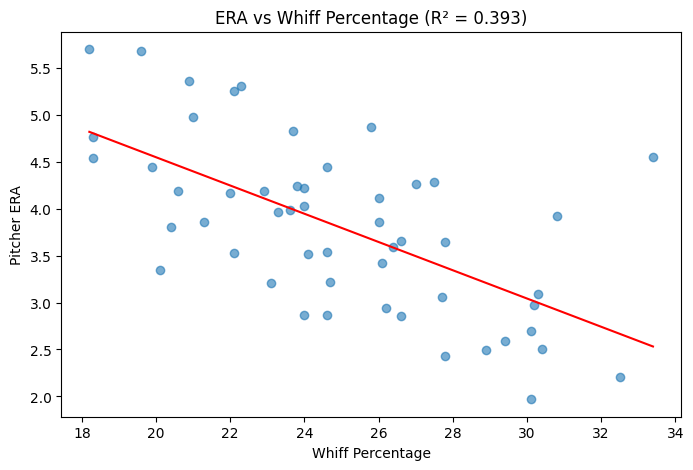

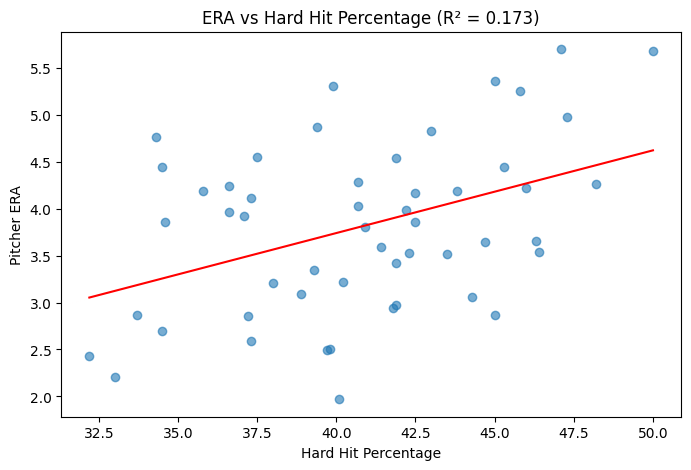

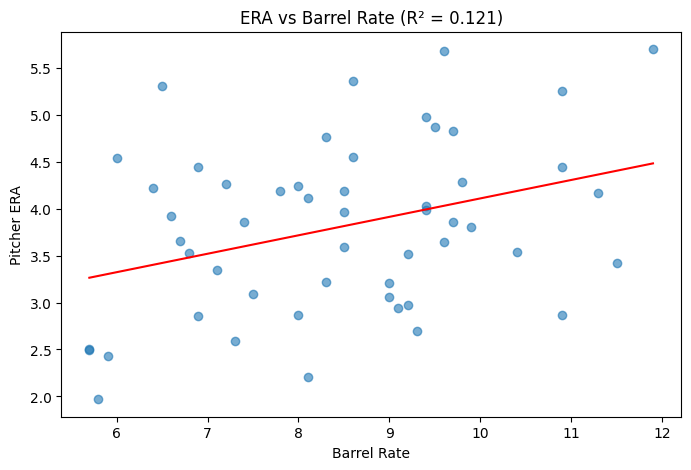

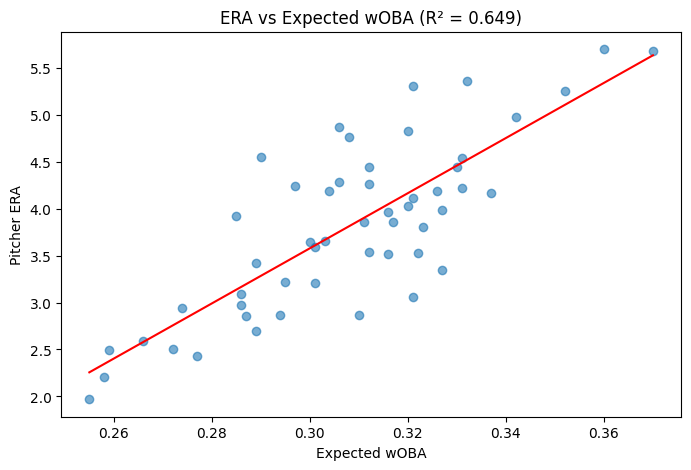

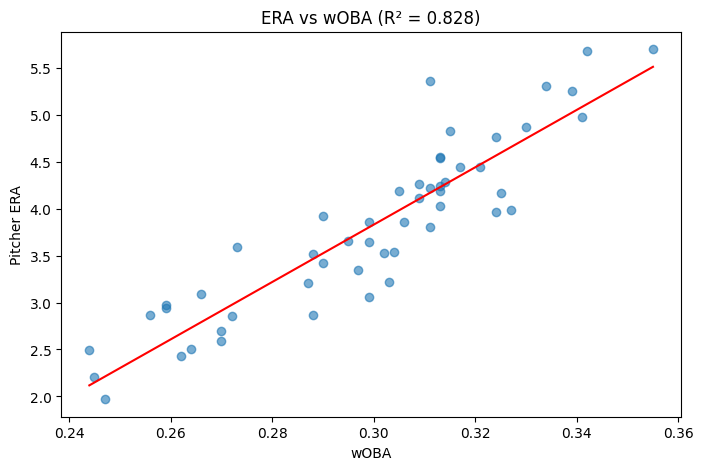

In [6]:
for x_col in predictors:

    x = df[x_col].to_numpy()
    y = df[target].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)
    y_hat = intercept + slope * x

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    order = np.argsort(x)

    plt.figure(figsize=(8,5))
    plt.scatter(x, y, alpha=0.6)
    plt.plot(x[order], y_hat[order], color="red")

    plt.title(f'ERA vs {labels[x_col]} (R² = {r2:.3f})')
    plt.xlabel(labels[x_col])
    plt.ylabel("Pitcher ERA")

    plt.show()

## Multiple Regression 

In [7]:
X = df[
    [
        "k_percent",
        "bb_percent",
        "whiff_percent",
        "hard_hit_percent",
        "barrel_batted_rate",
        "xwoba"
    ]
].copy()

X = sm.add_constant(X)
y = df[target]

model = sm.OLS(y, X).fit()

print("\nMultiple regression: ERA ~ K% + BB% + Whiff% + HardHit% + Barrel% + xwOBA")
print(model.summary())


Multiple regression: ERA ~ K% + BB% + Whiff% + HardHit% + Barrel% + xwOBA
                            OLS Regression Results                            
Dep. Variable:                  p_era   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     14.90
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.71e-09
Time:                        14:37:55   Log-Likelihood:                -39.890
No. Observations:                  52   AIC:                             93.78
Df Residuals:                      45   BIC:                             107.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

## Predictor Rankings 

In [8]:
rank = corr[target].drop(target).abs().sort_values(ascending=False)

print("\nPredictors ranked by |correlation| with ERA:")
print(rank)


Predictors ranked by |correlation| with ERA:
woba                  0.909677
xwoba                 0.805489
k_percent             0.707090
whiff_percent         0.627148
hard_hit_percent      0.416407
barrel_batted_rate    0.347813
bb_percent            0.184958
Name: p_era, dtype: float64


## Key Takeaways